<a href="https://colab.research.google.com/github/Tulasipriya-yellanki/AI-Deep-Learning/blob/main/ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
!pip install keras-tuner
!pip install tensorflow

In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import layers, models
import keras_tuner as kt
import pickle
import os



In [80]:
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

In [81]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [82]:
pd.set_option('display.max_columns', None)

In [83]:
df['gender'].value_counts()
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [85]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [86]:
df.duplicated().sum()

np.int64(0)

In [87]:
df.shape

(7043, 21)

In [88]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [89]:
df.head(2)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [90]:
df['TotalCharges']=pd.to_numeric((df['TotalCharges']),errors='coerce')
df['gender']=df['gender'].map({"Female":0,"Male":1})
df['Churn']=df['Churn'].map({'No':0,'Yes':1})

In [91]:
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [92]:
df.dropna(inplace=True)

In [93]:
df.isnull().sum().sum()

np.int64(0)

In [94]:
# null - consider compltely empty- row-wise
# nan- something is their but Datatype is not define(batch-wise)

In [95]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

In [96]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

Selected features by RFE: ['tenure', 'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

Feature importances:
             feature  importance
18      TotalCharges    0.191946
17    MonthlyCharges    0.178952
4             tenure    0.152571
14          Contract    0.078829
16     PaymentMethod    0.055766
8     OnlineSecurity    0.045120
11       TechSupport    0.043974
0             gender    0.028073
15  PaperlessBilling    0.025130
7    InternetService    0.024460
9       OnlineBackup    0.023808
10  DeviceProtection    0.023422
2            Partner    0.023004
6      MultipleLines    0.022363
1      SeniorCitizen    0.021023
13   StreamingMovies    0.019961
3         Dependents    0.019291
12       StreamingTV    0.017975
5       PhoneService    0.004330


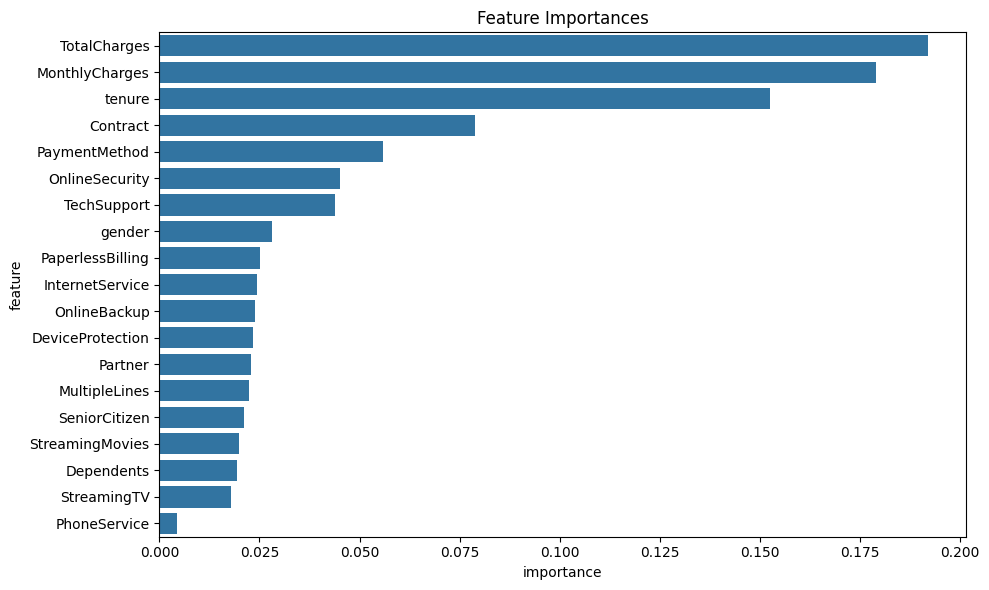

In [97]:
#FEATURE SELECTION USING RFE
numerical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

for col in numerical_features:
    if df[col].dtype == 'object':
        df[col] = pd.factorize(df[col])[0]

numerical_features = [f for f in numerical_features if f in df.columns]

X = df[numerical_features]
y = df['Churn']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=5)
rfe.fit(X, y)

selected_features = [feature for feature, selected in
                     zip(numerical_features, rfe.support_) if selected]
print(f"Selected features by RFE: {selected_features}")

rf.fit(X, y)
importances = pd.DataFrame({'feature': numerical_features,
                            'importance': rf.feature_importances_})
importances = importances.sort_values('importance', ascending=False)
print("\nFeature importances:")
print(importances)

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importances)
plt.title('Feature Importances')
plt.tight_layout()
plt.show()

In [98]:
X = df[selected_features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=10)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

In [107]:
def create_model(hp=None):
    if hp:
        model = models.Sequential()
        model.add(layers.Dense(
            units=hp.Choice('units_1', values=[32, 64, 128]),
            activation='relu',
            input_shape=(X_train_scaled.shape[1],)
        ))
        if hp.Boolean('second_layer'):
            model.add(layers.Dense(
                units=hp.Choice('units_2', values=[16, 32]),
                activation='relu'
            ))
        model.add(layers.Dense(1, activation='sigmoid'))
        model.compile(
            optimizer='adam',
            loss='binary_crossentropy',
            metrics=['accuracy']
        )
    else:
      #5 ---> hl1(64) ----> hl2(32) ----> hl3(16) ----> hl4(8) ----->1
        model = models.Sequential([
            layers.Dense(64, activation='relu',
                         input_shape=(X_train_scaled.shape[1],)),
            layers.Dense(32, activation='relu'),
            layers.Dense(16, activation='relu'),
            layers.Dense(8, activation='relu'),
            layers.Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer="adam", loss='binary_crossentropy',
                      metrics=['accuracy'])

    return model

initial_model = create_model()
initial_model.summary()

history = initial_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7120 - loss: 0.5338 - val_accuracy: 0.7751 - val_loss: 0.4376
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7698 - loss: 0.4461 - val_accuracy: 0.7911 - val_loss: 0.4353
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7818 - loss: 0.4508 - val_accuracy: 0.7813 - val_loss: 0.4317
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7845 - loss: 0.4340 - val_accuracy: 0.7911 - val_loss: 0.4256
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7949 - loss: 0.4274 - val_accuracy: 0.7964 - val_loss: 0.4254
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7854 - loss: 0.4433 - val_accuracy: 0.7876 - val_loss: 0.4261
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7952 - loss: 0.4285 - val_accuracy: 0.7867 - val_loss: 0.4281
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7980 - loss: 0.4280 - val_accuracy: 0

In [100]:
loss, accuracy = initial_model.evaluate(X_test_scaled, y_test)
print(f"Initial Model - Test Loss: {loss}")
print(f"Initial Model - Test Accuracy: {accuracy}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8179 - loss: 0.4011
Initial Model - Test Loss: 0.4054754972457886
Initial Model - Test Accuracy: 0.810234546661377


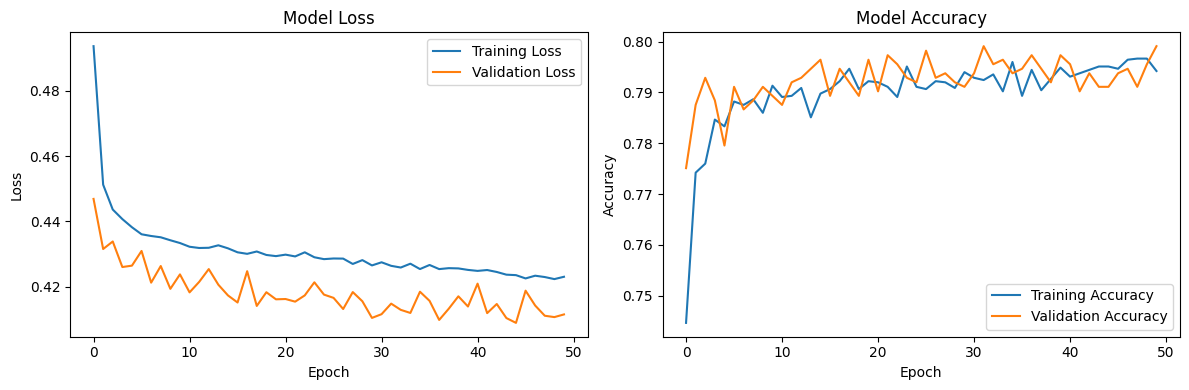

In [101]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.tight_layout()

In [102]:
tuner = kt.RandomSearch(
    create_model,
    objective='val_accuracy',
    max_trials=5,
    directory = 'keras_tuning'
)

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                  patience=3)

tuner.search(X_train_scaled, y_train,
             epochs=50,
             validation_split=0.20,
             callbacks=[early_stopping])

Reloading Tuner from keras_tuning/untitled_project/tuner0.json


In [103]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
for param in best_hps.values:
  print(f"{param} : {best_hps.get(param)}")

units_1 : 128
second_layer : False
units_2 : 32


In [104]:
best_hps = tuner.get_best_hyperparameters(num_trials=3)
for i, hp in enumerate(best_hps):
  print(f"Rank {i+1}: {hp.values}")

Rank 1: {'units_1': 128, 'second_layer': False, 'units_2': 32}
Rank 2: {'units_1': 128, 'second_layer': True, 'units_2': 16}
Rank 3: {'units_1': 32, 'second_layer': True, 'units_2': 16}


In [108]:
#use them directly to train my model
best_model = tuner.hypermodel.build(best_hps)
best_history = best_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    validation_split=0.20,
)

AttributeError: 'list' object has no attribute 'Choice'

In [ ]:
plt.figure(figsize=(12, 4))
plt.plot(best_history.history['loss'], label='Training Loss')
plt.plot(best_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()

In [ ]:
best_model.save("best_churn_model.h5")

In [ ]:
#seldcted features?
with open('selected_features.pkl','wb') as f:
  pickle.dump(selected_features, f)

In [ ]:
#predictions?  write read -save w, read - r
def load_model_components():
  model = tf.keras.models.load_model("best_churn_model.h5")
  with open('scaler.pkl','rb') as f:
    scaler = pickle.load(f)
  with open('selected_features.pkl','rb') as f:
    selected_features = pickle.load(f)
  return model, scaler, selected_features

def predict_churn(*args):
  model, scaler, selected_features = load_model_components()
  input_data = pd.DataFrame([args], columns=selected_features)
  input_scaled = scaler.transform(input_data)
  prediction = model.predict(input_scaled)[0][0]
  # print(f"prediction : {prediction}")
  probability = float(prediction)
  churn_status = "Yes" if probability > 0.5 else "No"

  return {
      "Churn Probability" : probability,
      "Will Churn?":churn_status
  }

In [ ]:
predict_churn(1,	0	,0	,29.85,	29.85)

In [ ]:
df[selected_features].head(2)

In [ ]:
predict_churn(4	,0	,1	,74.40	,306.6)

In [ ]:
df[selected_features][56:59]

In [ ]:
y[56:59]

In [ ]:
predict_churn(63,	1	,3,	99.65,	6311.20)